In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# XGBoost
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")

In [23]:
House_rent_dataset  = pd.read_csv("House_rent_Dataset.csv")
print(House_rent_dataset.head())

    Posted On  BHK   Rent  Size            Floor    Area Type  \
0  2022-05-18    2  10000  1100  Ground out of 2   Super Area   
1  2022-05-13    2  20000   800       1 out of 3   Super Area   
2  2022-05-16    2  17000  1000       1 out of 3   Super Area   
3  2022-07-04    2  10000   800       1 out of 2   Super Area   
4  2022-05-09    2   7500   850       1 out of 2  Carpet Area   

              Area Locality     City Furnishing Status  Tenant Preferred  \
0                    Bandel  Kolkata       Unfurnished  Bachelors/Family   
1  Phool Bagan, Kankurgachi  Kolkata    Semi-Furnished  Bachelors/Family   
2   Salt Lake City Sector 2  Kolkata    Semi-Furnished  Bachelors/Family   
3               Dumdum Park  Kolkata       Unfurnished  Bachelors/Family   
4             South Dum Dum  Kolkata       Unfurnished         Bachelors   

   Bathroom Point of Contact  
0         2    Contact Owner  
1         1    Contact Owner  
2         1    Contact Owner  
3         1    Contact Owner

In [24]:
House_rent_dataset

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner
...,...,...,...,...,...,...,...,...,...,...,...,...
4741,2022-05-18,2,15000,1000,3 out of 5,Carpet Area,Bandam Kommu,Hyderabad,Semi-Furnished,Bachelors/Family,2,Contact Owner
4742,2022-05-15,3,29000,2000,1 out of 4,Super Area,"Manikonda, Hyderabad",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Owner
4743,2022-07-10,3,35000,1750,3 out of 5,Carpet Area,"Himayath Nagar, NH 7",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Agent
4744,2022-07-06,3,45000,1500,23 out of 34,Carpet Area,Gachibowli,Hyderabad,Semi-Furnished,Family,2,Contact Agent


In [25]:
House_rent_dataset.describe()


,BHK,Rent,Size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


In [26]:
House_rent_dataset.isnull().sum

<bound method DataFrame.sum of       Posted On    BHK   Rent   Size  Floor  Area Type  Area Locality   City  \
0         False  False  False  False  False      False          False  False   
1         False  False  False  False  False      False          False  False   
2         False  False  False  False  False      False          False  False   
3         False  False  False  False  False      False          False  False   
4         False  False  False  False  False      False          False  False   
...         ...    ...    ...    ...    ...        ...            ...    ...   
4741      False  False  False  False  False      False          False  False   
4742      False  False  False  False  False      False          False  False   
4743      False  False  False  False  False      False          False  False   
4744      False  False  False  False  False      False          False  False   
4745      False  False  False  False  False      False          False  False   

      Fu

In [27]:
# Drop unnecessary columns
House_rent_dataset = House_rent_dataset.drop(columns=['Posted On'], errors='ignore')

# Handle missing values
House_rent_dataset = House_rent_dataset.dropna()

# Encode categorical features
le = LabelEncoder()
for col in House_rent_dataset.select_dtypes(include='object').columns:
    House_rent_dataset[col] = le.fit_transform(House_rent_dataset[col])

In [28]:
def rent_category(x):
    if x < 10000:
        return 0   # Low
    elif x < 30000:
        return 1   # Medium
    else:
        return 2   # High

House_rent_dataset['Rent_Category'] = House_rent_dataset['Rent'].apply(rent_category)

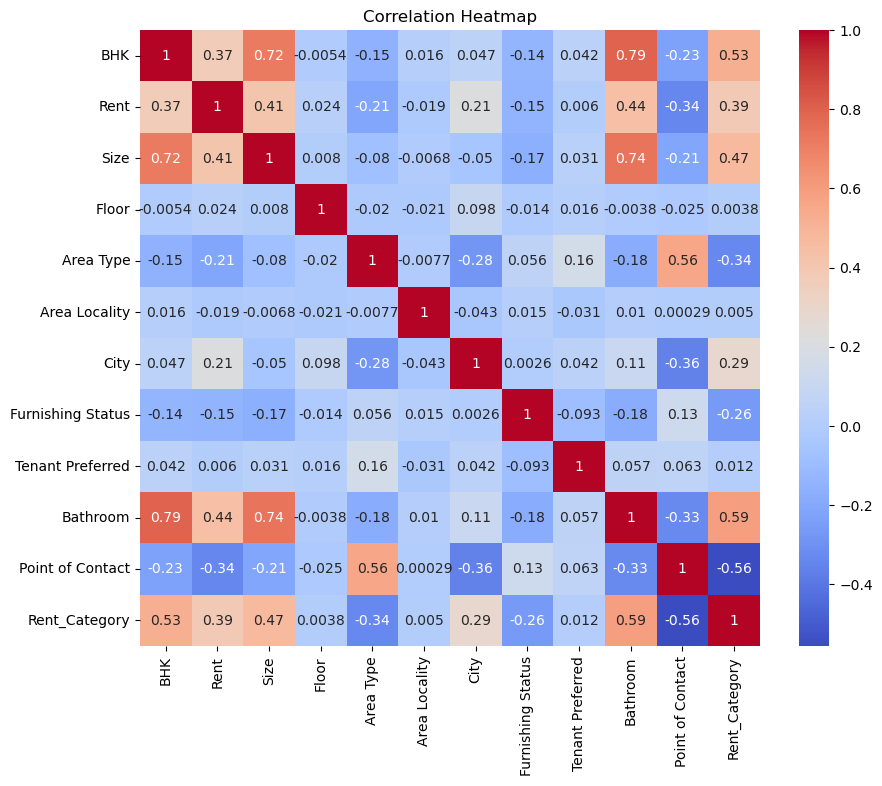

In [29]:
plt.figure(figsize=(10,8))
sns.heatmap(House_rent_dataset.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [30]:
X = House_rent_dataset.drop(['Rent', 'Rent_Category'], axis=1)
y = House_rent_dataset['Rent_Category']

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [33]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

In [34]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append([name, acc, prec, rec, f1])

results_House_rent_dataset = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score"
])

print(results_House_rent_dataset)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.746316   0.746136  0.746316  0.745521
1        Decision Tree  0.708421   0.709078  0.708421  0.708711
2        Random Forest  0.796842   0.797885  0.796842  0.797037
3                  KNN  0.740000   0.748086  0.740000  0.741158
4                  SVM  0.777895   0.785023  0.777895  0.776266
5              XGBoost  0.792632   0.792689  0.792632  0.792554


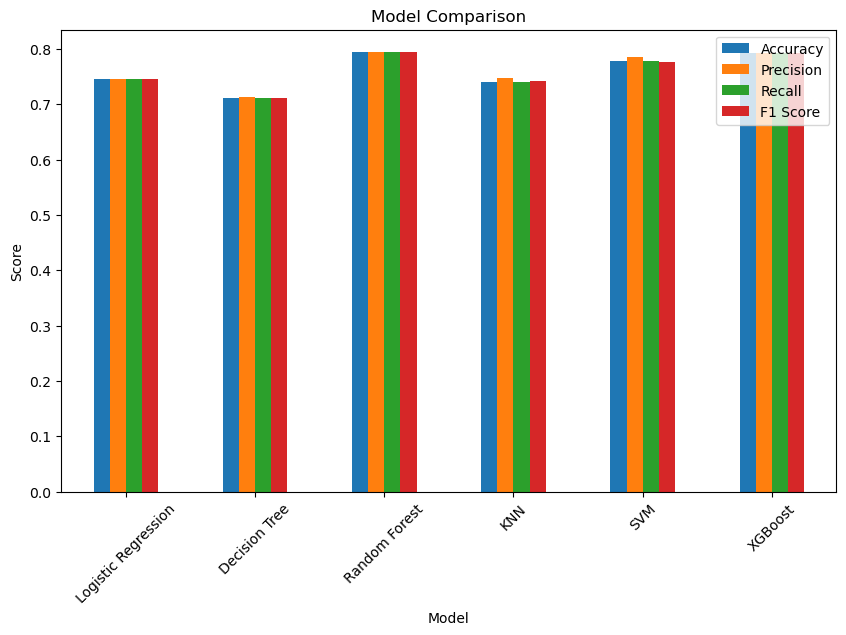

In [35]:
results_df.set_index("Model").plot(kind='bar', figsize=(10,6))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

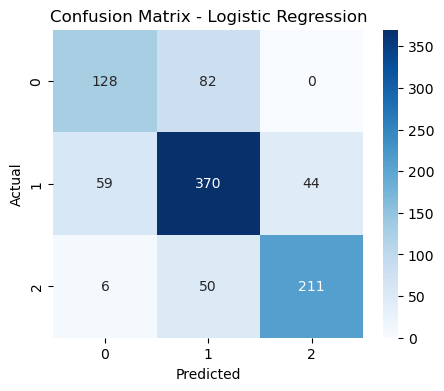

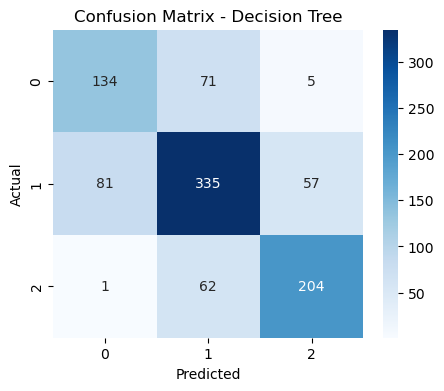

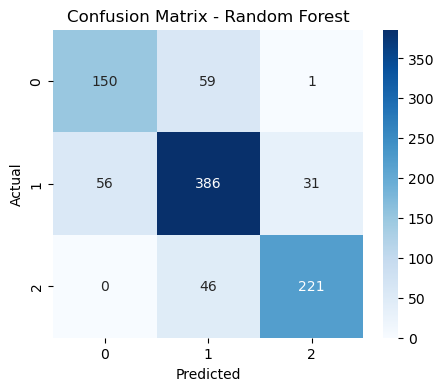

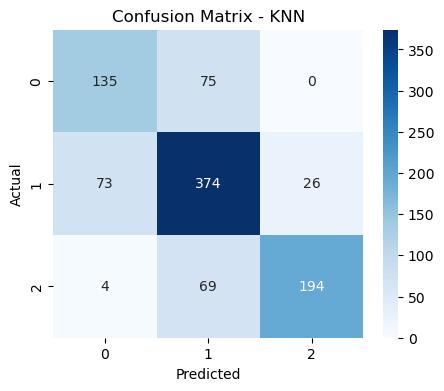

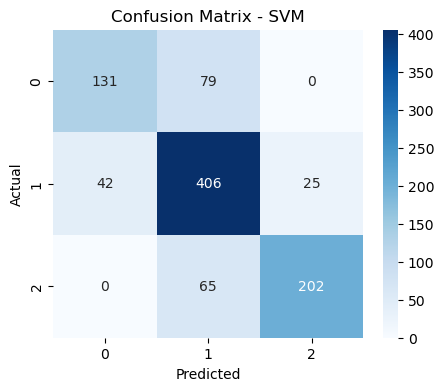

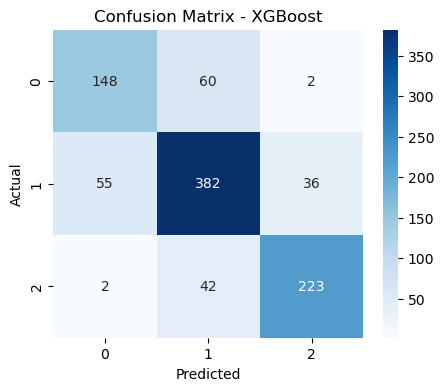

In [36]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [37]:
best_model = results_df.loc[results_df['Accuracy'].idxmax()]
print("\nBest Model Based on Accuracy:")
print(best_model)


Best Model Based on Accuracy:
Model        Random Forest
Accuracy          0.793684
Precision         0.794932
Recall            0.793684
F1 Score          0.793793
Name: 2, dtype: object
